In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=2, suppress=True)

## Generating synthetic data sets

### Generating blobs for clustering scenarios

In [3]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

X.shape  # coordinates (x, y) for 10 samples
y.shape  # classes for 10 samples

(100, 2)

(100,)

In [4]:
X[:5]
y[:5]

array([[-7.73, -8.39],
       [ 5.45,  0.74],
       [-2.98,  9.56],
       [ 6.04,  0.57],
       [-6.52, -6.32]])

array([2, 1, 0, 1, 2])

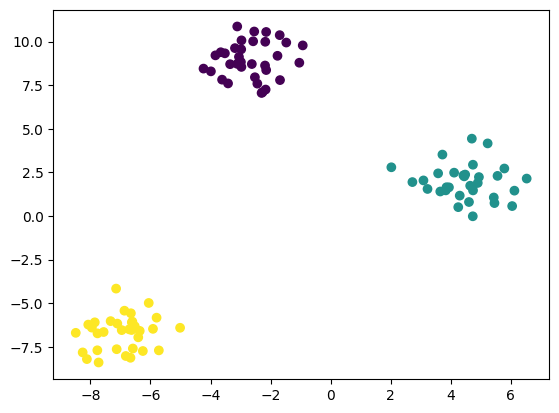

In [5]:
_ = plt.scatter(X[:, 0], X[:, 1], c=y)  # Observe the clusters

### Generating circles for non linear scenarios

In [6]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=100, noise=0.02, random_state=42)

X.shape  # coordinates
y.shape  # classes

(100, 2)

(100,)

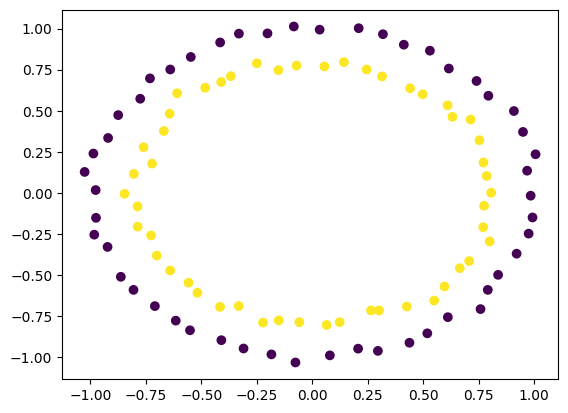

In [7]:
_ = plt.scatter(X[:, 0], X[:, 1], c=y)

## Imputation (Filling missing values)

In [8]:
from sklearn.impute import SimpleImputer

X = [[20, 100],
     [24, np.nan],
     [18, 90],
     [np.nan, 145]]

imputer = SimpleImputer(strategy='mean')
imputer.fit(X)  # fit ONLY on train data
imputer.transform(X)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


array([[ 20.  , 100.  ],
       [ 24.  , 111.67],
       [ 18.  ,  90.  ],
       [ 20.67, 145.  ]])

In [9]:
# use already fitted imputer to transform test data
# NEVER fit on test data
imputer.transform([
    [np.nan, 116],
    [32, np.nan],
])

array([[ 20.67, 116.  ],
       [ 32.  , 111.67]])

In [10]:
imp = SimpleImputer(missing_values=np.nan, strategy='median')
X = [[4, 1], [np.nan, 5], [8, 0]]
imp . fit_transform(X)

array([[4., 1.],
       [6., 5.],
       [8., 0.]])

### Handling a messy data

In [11]:
data = {
    'Roll': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    'Age': [30, 0, 27, 30, 25, np.nan, 22, 28, np.nan, 35],
    'Country': ['USA', 'France', 'China', '-', 'Sweden', 'UK', 'Japan', 'Brazil', '?', 'India'],
    'Course': ['?', 'Math', 'English', 'NaN', 'Science', 'NULL', 'History', 'Art', '-', 'Math'],
    'Score': [15, 9999, 78, 22, 65, 48, 85, 90, -1, 55],
    'Result': ['F', 'Pass', 'NA', 'Fail', 'Unknown', 'Pass', 'Pass', 'F', 'Pass', 'NaN']
}

df = pd.DataFrame(data)
df

,Roll,Age,Country,Course,Score,Result
0,1001,30.0,USA,?,15,F
1,1002,0.0,France,Math,9999,Pass
2,1003,27.0,China,English,78,NA
3,1004,30.0,-,NaN,22,Fail
4,1005,25.0,Sweden,Science,65,Unknown
5,1006,NaN,UK,NULL,48,Pass
6,1007,22.0,Japan,History,85,Pass
7,1008,28.0,Brazil,Art,90,F
8,1009,NaN,?,-,-1,Pass
9,1010,35.0,India,Math,55,NaN


In [12]:
df.isnull().sum()

Roll       0
Age        2
Country    0
Course     0
Score      0
Result     0
dtype: int64

In [13]:
# List the specific strings to identify as missing
missing_markers = ['-', '?', 'NA', 'NULL', 'Unknown', 'NaN']

# Replace them with np.nan
df = df.replace(missing_markers, np.nan)
df.isnull().sum()

Roll       0
Age        2
Country    2
Course     4
Score      0
Result     3
dtype: int64

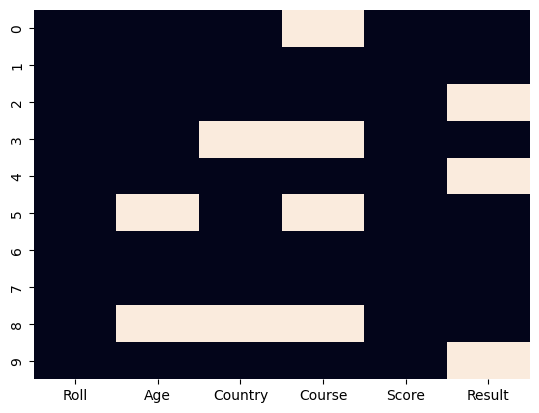

In [14]:
import seaborn as sns
_ = sns.heatmap(df.isnull(), cbar=False)

## Categorical Transformers

### One-Hot Encoding

In [15]:
data = {
    'ID': range(1, 11),
    'Score': [85, 70, 92, 65, 88, 75, 80, 95, 60, 77],
    'Country': ['USA', 'India', 'UK', 'Canada', 'USA', 'India', 'UK', 'Canada', 'USA', 'India']
}

df = pd.DataFrame(data)
df.head()

,ID,Score,Country
0,1,85,USA
1,2,70,India
2,3,92,UK
3,4,65,Canada
4,5,88,USA


In [16]:
df_encoded = pd.get_dummies(df, columns=['Country'])
df_encoded.head()

,ID,Score,Country_Canada,Country_India,Country_UK,Country_USA
0,1,85,False,False,False,True
1,2,70,False,True,False,False
2,3,92,False,False,True,False
3,4,65,True,False,False,False
4,5,88,False,False,False,True


### LabelEncoder

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_copy = df.copy()
df_copy['Country'] = le.fit_transform(df['Country'])
df_copy.head()
le.classes_

,ID,Score,Country
0,1,85,3
1,2,70,1
2,3,92,2
3,4,65,0
4,5,88,3


array(['Canada', 'India', 'UK', 'USA'], dtype=object)

### LabelBinarizer

Used for multiclass targets where each row belongs to exactly one category. It converts a single column of $n$ classes into $n$ binary columns.

In [18]:
from sklearn.preprocessing import LabelBinarizer

countries = ['USA', 'India', 'UK', 'USA', 'India']

lb = LabelBinarizer()
lb.fit_transform(countries)
lb.classes_

array([[0, 0, 1],
       [1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [1, 0, 0]])

array(['India', 'UK', 'USA'], dtype='<U5')

### MultiLabelBinarizer

Used for multilabel targets where each row can belong to multiple categories simultaneously (represented as a list or tuple).

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer

genres = [('Action', 'Comedy'),
          ('Action',),
          ('Action', 'Sci-Fi'),
          ('Drama', 'Action'),
          ('Comedy',),
          ('Sci-Fi',)]

mlb = MultiLabelBinarizer()
mlb.fit_transform(genres)
mlb.classes_

array([[1, 1, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 1],
       [1, 0, 1, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1]])

array(['Action', 'Comedy', 'Drama', 'Sci-Fi'], dtype=object)

### OneHotEncoder

Use this only for categorical columns.

In [20]:
from sklearn.preprocessing import OneHotEncoder

X = np.array([
    ('apple',  'India', 100),
    ('banana', 'India',  90),
    ('litchi', 'India',  110),
    ('banana', 'India',  40),
    ('apple', 'USA', 120),
    ('litchi', 'USA',  160),])

ohe = OneHotEncoder(sparse_output=False)
ohe.fit_transform(X[:, :2])
ohe.get_feature_names_out(['fruit', 'country'])

array([[1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.]])

array(['fruit_apple', 'fruit_banana', 'fruit_litchi', 'country_India',
       'country_USA'], dtype=object)

In [21]:
X = np.array([[5],
              [2],
              [5],
              [9],
              [9],
              [9]])

ohe = OneHotEncoder(sparse_output=False)
ohe.fit_transform(X)
ohe.get_feature_names_out(['cgpa'])

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

array(['cgpa_2', 'cgpa_5', 'cgpa_9'], dtype=object)

### Looking into activity questions

In [22]:
X = [{'Heart-disease', 'Diabetes'},
     {'High-BP'},
     {'Heart-disease', 'High-BP'},
     {'Diabetes'}]

mlb = MultiLabelBinarizer()
mlb.fit_transform(X)
mlb.classes_

array([[1, 1, 0],
       [0, 0, 1],
       [0, 1, 1],
       [1, 0, 0]])

array(['Diabetes', 'Heart-disease', 'High-BP'], dtype=object)

In [23]:
from sklearn.preprocessing import add_dummy_feature

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
X = [[3, 8], [1, 4], [8, np.nan]]
add_dummy_feature(imp.fit_transform(X))

array([[1., 3., 8.],
       [1., 1., 4.],
       [1., 8., 6.]])

In [24]:
lb = LabelBinarizer()
lb.fit_transform(['yes', 'yes', 'no', 'yes'])

array([[1],
       [1],
       [0],
       [1]])

## Numeric transformations

### Feature scaling

In [25]:
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, StandardScaler

data = {
    'Salary': [50000, 80000, 120000, 45000, 95000, 110000, 60000, 75000, 130000, 52000],
    'Experience': [1, 5, 10, 0, 7, 9, 2, 4, 12, 1]
}
df = pd.DataFrame(data)
df.head()

,Salary,Experience
0,50000,1
1,80000,5
2,120000,10
3,45000,0
4,95000,7


In [26]:
# MinMaxScaler: Scales in range [0, 1]
scalar = MinMaxScaler()
df_scaled = pd.DataFrame(scalar.fit_transform(df), columns=df.columns)
df_scaled.head()
df_scaled.min()
df_scaled.max()

,Salary,Experience
0,0.058824,0.083333
1,0.411765,0.416667
2,0.882353,0.833333
3,0.000000,0.000000
4,0.588235,0.583333


Salary        0.0
Experience    0.0
dtype: float64

Salary        1.0
Experience    1.0
dtype: float64

In [27]:
# MaxAbsScaler: Scales by maximum absolute value, range [-1, 1]
scalar = MaxAbsScaler()
df_scaled = pd.DataFrame(scalar.fit_transform(df), columns=df.columns)
df_scaled.head()

,Salary,Experience
0,0.384615,0.083333
1,0.615385,0.416667
2,0.923077,0.833333
3,0.346154,0.000000
4,0.730769,0.583333


In [28]:
# StandardScaler: Scales to Mean = 0, Std Dev = 1
scalar = StandardScaler()
df_scaled = pd.DataFrame(scalar.fit_transform(df), columns=df.columns)
df_scaled.head()
df_scaled.mean()
df_scaled.std()

,Salary,Experience
0,-1.085381,-1.022129
1,-0.058207,-0.024930
2,1.311359,1.221569
3,-1.256577,-1.271429
4,0.455381,0.473670


Salary       -2.220446e-17
Experience    6.661338e-17
dtype: float64

Salary        1.054093
Experience    1.054093
dtype: float64

### Function transformers

In [29]:
np.log(np.e**2)
np.log2(16)
np.log10(100)

np.float64(2.0)

np.float64(4.0)

np.float64(2.0)

In [30]:
np.log(0)
np.log1p(0)  # natural logarithm of 1 + x (i.e., ln(1 + x))

C:\Users\k26ra\AppData\Local\Temp\ipykernel_4900\142382267.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(0)


np.float64(-inf)

np.float64(0.0)

In [31]:
from sklearn.preprocessing import FunctionTransformer

df = pd.DataFrame({'Revenue': [100, 500, 2000, 10000, 50000]})

log_transformer = FunctionTransformer(np.log1p)
log_transformer.transform(df)

,Revenue
0,4.615121
1,6.216606
2,7.601402
3,9.210440
4,10.819798


In [32]:
from sklearn.preprocessing import FunctionTransformer

X = [[10, 4000],
     [12, 2000],
     [8, 1000],
     [22, 4500],
     [20, 2500]]

transformer = FunctionTransformer(np.mean)
transformer.transform(X)
np.sum(X) / 10
np.mean(X)

np.float64(1407.2)

np.float64(1407.2)

np.float64(1407.2)

### Generating polynomial features

Degree 2: Generates $[1, x_1, x_2, x_1^2, x_1x_2, x_2^2]$.

Degree 3: Adds higher-order terms like $[x_1^3, x_1^2x_2, x_1x_2^2, x_2^3]$.

The first column is always 1 (the bias term) unless you set include_bias=False.

In [33]:
from sklearn.preprocessing import PolynomialFeatures

data = {
    'x1': [1, 2, 3, 4, 5],
    'x2': [2, 4, 1, 3, 2]
}
df = pd.DataFrame(data)
df

,x1,x2
0,1,2
1,2,4
2,3,1
3,4,3
4,5,2


In [34]:
# Degree 2 Transformation
poly2 = PolynomialFeatures(degree=2)
pd.DataFrame(poly2.fit_transform(df), columns=poly2.get_feature_names_out())

,1,x1,x2,x1^2,x1 x2,x2^2
0,1.0,1.0,2.0,1.0,2.0,4.0
1,1.0,2.0,4.0,4.0,8.0,16.0
2,1.0,3.0,1.0,9.0,3.0,1.0
3,1.0,4.0,3.0,16.0,12.0,9.0
4,1.0,5.0,2.0,25.0,10.0,4.0


In [35]:
# Degree 3 Transformation
poly3 = PolynomialFeatures(degree=3)
pd.DataFrame(poly3.fit_transform(df), columns=poly3.get_feature_names_out())

,1,x1,x2,x1^2,x1 x2,x2^2,x1^3,x1^2 x2,x1 x2^2,x2^3
0,1.0,1.0,2.0,1.0,2.0,4.0,1.0,2.0,4.0,8.0
1,1.0,2.0,4.0,4.0,8.0,16.0,8.0,16.0,32.0,64.0
2,1.0,3.0,1.0,9.0,3.0,1.0,27.0,9.0,3.0,1.0
3,1.0,4.0,3.0,16.0,12.0,9.0,64.0,48.0,36.0,27.0
4,1.0,5.0,2.0,25.0,10.0,4.0,125.0,50.0,20.0,8.0


### KBinsDiscretizer

In [36]:
from sklearn.preprocessing import KBinsDiscretizer

data = {'Age': [10, 12, 15, 9, 11, 10, 17, 15, 10, 6, 40, 30, 90]}
df = pd.DataFrame(data)
df.head()

,Age
0,10
1,12
2,15
3,9
4,11


- n_bins=3 creates 3 groups (e.g., Young, Middle, Senior)
- encode='ordinal' returns 0, 1, 2 instead of one-hot vectors
- strategy='quantile' ensures an equal number of samples in each bin

In [37]:
type(df['Age'])
type(df[['Age']])

pandas.Series

pandas.DataFrame

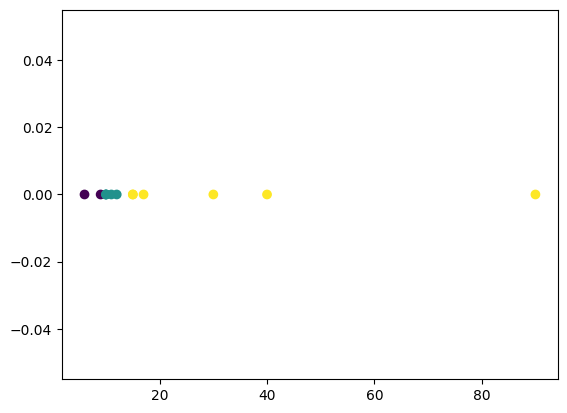

In [38]:
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile',
                       quantile_method='averaged_inverted_cdf')
bins = kbd.fit_transform(df[['Age']])
_ = plt.scatter(df['Age'], [0]*len(df), c=bins)

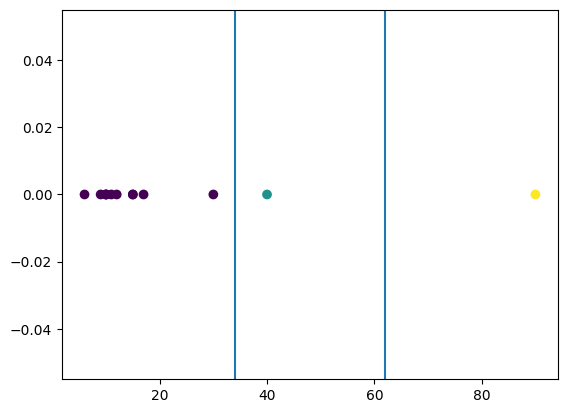

In [39]:
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
bins = kbd.fit_transform(df[['Age']])

age_min = df['Age'].min()
age_max = df['Age'].max()
cw = (age_max - age_min) / 3
boundaries = np.arange(age_min, age_max, cw)[1:]

_ = plt.scatter(df['Age'], [0]*len(df), c=bins)
_ = plt.axvline(boundaries[0])
_ = plt.axvline(boundaries[1])

## Outliers

In [40]:
data = {
    'Annual_Income_k': [45, 52, 48, 60, 55, 300, 50, 47, 58, 1000],  # Outliers: 300 and 1000
    'Property_Age': [5, 2, 8, 4, 1, 150, 6, 3, 9, 250]               # Outliers: 150 and 250
}

df = pd.DataFrame(data)
df

,Annual_Income_k,Property_Age
0,45,5
1,52,2
2,48,8
3,60,4
4,55,1
5,300,150
6,50,6
7,47,3
8,58,9
9,1000,250


In [41]:
df.describe()

,Annual_Income_k,Property_Age
count,10.000000,10.000000
mean,171.500000,43.800000
std,301.405688,85.668353
min,45.000000,1.000000
25%,48.500000,3.250000
50%,53.500000,5.500000
75%,59.500000,8.750000
max,1000.000000,250.000000


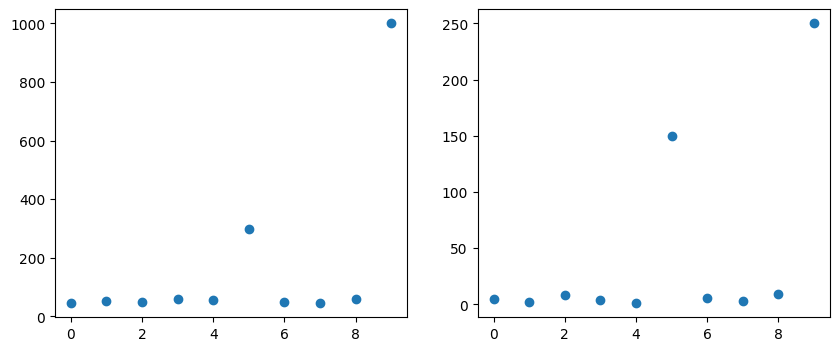

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
_ = ax[0].scatter(df.index, df['Annual_Income_k'])
_ = ax[1].scatter(df.index, df['Property_Age'])

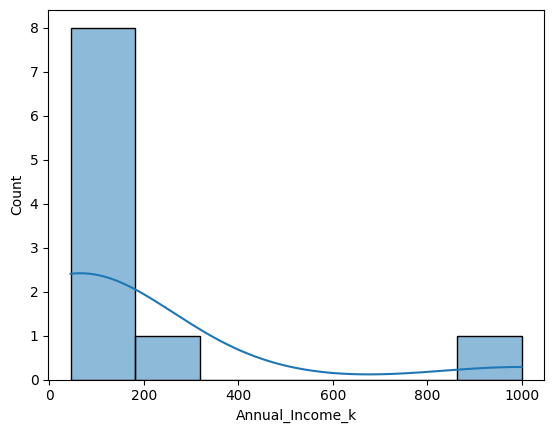

In [43]:
_ = sns.histplot(df['Annual_Income_k'], kde=True)

In [44]:
data = np.array([10, 12, 13, 15, 16, 18, 20, 22, 100, -50])

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
q1 = np.percentile(data, 25)
q3 = np.percentile(data, 75)

# Calculate IQR
iqr = q3 - q1

# Define bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter outliers
filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]

print(f"IQR: {iqr}")
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
print(f"Filtered Data: {filtered_data}")

IQR: 7.25
Lower Bound: 1.375, Upper Bound: 30.375
Filtered Data: [10 12 13 15 16 18 20 22]


In [45]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

X = np.array([[1, 'yes'], [2, 'no'], [3, 'no']])
ct = ColumnTransformer([('scaler', MinMaxScaler(), [0]),
                        ('pass', 'passthrough', [0]),
                        ('encoder', OrdinalEncoder(), [1])])

print(ct.fit_transform(X))

[['0.0' '1' '1.0']
 ['0.5' '2' '0.0']
 ['1.0' '3' '0.0']]
